# Programming Task

Design and Creative Technologies, Torrens Unversity

- Student: Luis Guilherme de Barros Andrade Faria - A00187785 
- Subject Code: ISY 503 
- Subject Name: Intelligent Systems 
- Assessment No.: 2
- Title of Assessment: Programming Task
- Lecturer: Dr. Nandini Sidnal
- Date: April 2026

Copyright © 2026 by Luis G B A Faria

*Permission is hereby granted to make and distribute verbatim copies of this document provided the copyright notice and this permission notice are preserved on all copies.*

### Libraries + Setup

In [12]:
%reset -f
import numpy as np
import pandas as pd
import math

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Set pandas output display to have one digit for decimal places and limit it to
# printing 15 rows.
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 15

### Loading the dataset 
The car data set we will be using in this lab is provided as a comma separated.
We will use the features of the car, to try to predict its price.


In [13]:
# Provide the names for the columns since the CSV file with the data does
# not have a header row.
feature_names = ['symboling', 'normalized-losses', 'make', 'fuel-type',
        'aspiration', 'num-doors', 'body-style', 'drive-wheels',
        'engine-location', 'wheel-base', 'length', 'width', 'height', 'weight',
        'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore',
        'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
        'highway-mpg', 'price']

# [Change #1]: dataset url
# old URL: https://storage.googleapis.com/mledu-datasets/cars_data.csv
# Load in the data from a CSV file that is comma separated using NEW URL
car_data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data',
                        sep=',', names=feature_names, header=None, encoding='latin-1')


# We'll then randomize the data, just to be sure not to get any pathological
# ordering effects that might harm the performance of Stochastic Gradient
# Descent.
car_data = car_data.reindex(np.random.permutation(car_data.index))

print("Data set loaded. Num examples: ", len(car_data))

Data set loaded. Num examples:  205


*This is a really small dataset! Only 205 examples.*

*For simplicity in this codelab, we do not split the data further into training and validation. But this is a MUST do on real datasets, or else it will overfit to single dataset.*

### Task 0: data prep/exploration with pandas

In [14]:
car_data[4:7]

,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
38,0,106,honda,gas,std,two,hatchback,fwd,front,96.50,...,110,1bbl,3.15,3.58,9.00,86,5800,27,33,9095
77,2,161,mitsubishi,gas,std,two,hatchback,fwd,front,93.70,...,92,2bbl,2.97,3.23,9.40,68,5500,31,38,6189
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.10,...,141,mpfi,3.78,3.15,8.70,160,5300,19,25,19045


In [15]:
# [Change #2]: Used to inspect data
# car_data.describe()
car_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 118 to 42
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-doors          205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  weight             205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-cylinders      205 non-null    object 
 16  engine-size        205 non-nul

In [16]:
LABEL = 'price'

# numeric_feature_names = car_data[[
# 'symboling','normalized-losses','wheel-base','engine-size','bore','stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']]

# [Change #3]: 
# After inspecting the dataset using car_data.describe() / car_data.info()
# I could find & adjust to 15 columns with continuous/ordinal numeric values
numeric_feature_names = [
    'symboling', 'normalized-losses', 'wheel-base',
    'length', 'width', 'height', 'weight', 'engine-size',
    'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg',
    'bore', 'stroke', 'compression-ratio'
]
categorical_feature_names = list(set(feature_names) - set(numeric_feature_names) - set([LABEL]))

# The correct solution will pass these assert statements.
assert len(numeric_feature_names) == 15
assert len(categorical_feature_names) == 10
print('Task 0 assertions passed.')

Task 0 assertions passed.


In [17]:
# Run to inspect numeric features.
car_data[numeric_feature_names]

,symboling,normalized-losses,wheel-base,length,width,height,weight,engine-size,horsepower,peak-rpm,city-mpg,highway-mpg,bore,stroke,compression-ratio
118,1,119,93.70,157.30,63.80,50.80,1918,90,68,5500,37,41,2.97,3.23,9.40
168,2,134,98.40,176.20,65.60,52.00,2536,146,116,4800,24,30,3.62,3.50,9.30
147,0,89,97.00,173.50,65.40,53.00,2455,108,94,5200,25,31,3.62,2.64,9.00
31,2,137,86.60,144.60,63.90,50.80,1819,92,76,6000,31,38,2.91,3.41,9.20
38,0,106,96.50,167.50,65.20,53.30,2289,110,86,5800,27,33,3.15,3.58,9.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2,161,93.70,157.30,64.40,50.80,1918,92,68,5500,37,41,2.97,3.23,9.40
110,0,?,114.20,198.90,68.40,58.70,3430,152,95,4150,25,25,3.70,3.52,21.00
121,1,154,93.70,167.30,63.80,50.80,1989,90,68,5500,31,38,2.97,3.23,9.40
9,0,?,99.50,178.20,67.90,52.00,3053,131,160,5500,16,22,3.13,3.40,7.00


In [18]:
# Run to inspect categorical features.
car_data[categorical_feature_names]

,drive-wheels,make,num-doors,aspiration,num-cylinders,engine-location,fuel-system,fuel-type,body-style,engine-type
118,fwd,plymouth,two,std,four,front,2bbl,gas,hatchback,ohc
168,rwd,toyota,two,std,four,front,mpfi,gas,hardtop,ohc
147,fwd,subaru,four,std,four,front,mpfi,gas,wagon,ohcf
31,fwd,honda,two,std,four,front,1bbl,gas,hatchback,ohc
38,fwd,honda,two,std,four,front,1bbl,gas,hatchback,ohc
...,...,...,...,...,...,...,...,...,...,...
76,fwd,mitsubishi,two,std,four,front,2bbl,gas,hatchback,ohc
110,rwd,peugot,four,turbo,four,front,idi,diesel,wagon,l
121,fwd,plymouth,four,std,four,front,2bbl,gas,sedan,ohc
9,4wd,audi,two,turbo,five,front,mpfi,gas,hatchback,ohc


In [19]:
# [Change #4]: Replace '?' with NaN first, then handle missing values properly.
# - Drop rows where price (the label) is missing — can't train without it.
# - Impute missing feature values with column mean — safer than 0 on a 205-row dataset.
for feature_name in numeric_feature_names + [LABEL]:
  car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')

# Drop rows with missing labels first
car_data = car_data[car_data[LABEL].notna() & (car_data[LABEL] > 0)].copy()

# Impute missing numeric features with column mean
for feature_name in numeric_feature_names:
  col_mean = car_data[feature_name].mean()
  car_data[feature_name] = car_data[feature_name].fillna(col_mean)

print(f"Rows after cleaning: {len(car_data)}")
print(f"Remaining NaNs in features: {car_data[numeric_feature_names].isna().sum().sum()}")

Rows after cleaning: 201
Remaining NaNs in features: 0


### Task 1: Make the best model with numeric features. No normalization allowed.

Modify the model provided below to achieve the lowest evaluation loss. 
You may want to change various hyperparameters:
- learning rate
- choice of optimizer
- hidden layer dimensions (make sure that choice here makes sense given the number of training examples)
- batch size
- num training steps
- anything else I can think of changing

Do not use the `normalizer_fn` arg on `numeric_column`.

In [ ]:
# [Change #5]: Replaced GradientDescentOptimizer with AdagradOptimizer.
# GradientDescentOptimizer uses a single global learning rate for all parameters.
# With unscaled features (weight ~3000 vs bore ~2.9), large-scale features produce
# large gradients that explode under a fixed lr=0.01, causing NaN loss.
# AdagradOptimizer maintains a per-parameter learning rate that shrinks as gradients
# accumulate — large-gradient parameters get a smaller effective lr automatically,
# handling the scale variance without requiring explicit normalization (Task 1 constraint).

# > GradientDescent is blind to feature scale. Adagrad isn't. On an unscaled dataset, that difference alone is worth an 83% reduction in loss.

# [Change #6]: Hyperparameter variables for easy tuning.
batch_size_parameter = 16
learning_rate_parameter = 0.01
hidden_units_parameter = [64]
optimizer_parameter = tf.train.AdagradOptimizer(learning_rate=learning_rate_parameter)

# Test results
# Run       │             Config             │ Final avg_loss │  RMSE (sqrt of avg_loss)
# *Run 1*   │ batch=16, hidden=[64], lr=0.01 │ 10,822,464     │ ~$3,290
# Run 2     │ batch=32, hidden=[32], lr=0.1  │ 12,703,589     │ ~$3,565
# Run 3     │ batch=32, hidden=[64], lr=0.01 │ 18,289,694     │ ~$4,276
# Run 4     │ batch=16, hidden=[64], lr=0.1  │ 19,032,338     │ ~$4,362

print(numeric_feature_names)
x_df = car_data[numeric_feature_names]
y_series = car_data['price']

# Create input_fn's so that the estimator knows how to read in your data.
train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size_parameter,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size_parameter,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size_parameter,
    shuffle=False)

# Feature columns allow the model to parse the data, perform common
# preprocessing, and automatically generate an input layer for the tf.Estimator.
model_feature_columns = [
    tf.feature_column.numeric_column(feature_name) for feature_name in numeric_feature_names
]
print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=hidden_units_parameter,
    optimizer=optimizer_parameter,
  )

# TRAIN
num_print_statements = 10
num_training_steps = 10000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)

  # The `scores` dictionary has several metrics auto-gen by canned Estimator.
  # `average_loss` is the average loss for an individual example.
  # `loss` is the summed loss for the batch.
  print('scores', scores)

### Visualize model's predictions

After you have a trained model, it may be helpful to understand how your model's inference differs from the actual data.

This helper function `scatter_plot_inference` does that for you. Real data is in grey. Your model's predictions are in orange.


INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from /var/folders/c4/t_n58l316yl308hxjf5jlwsh0000gn/T/tmp8418b0ux/model.ckpt-10000
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.


2026-03-22 11:58:15.736129: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-22 11:58:15.736158: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-03-22 11:58:15.758252: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-22 11:58:15.805672: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-22 11:58:15.813099: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-22 11:58:15.81

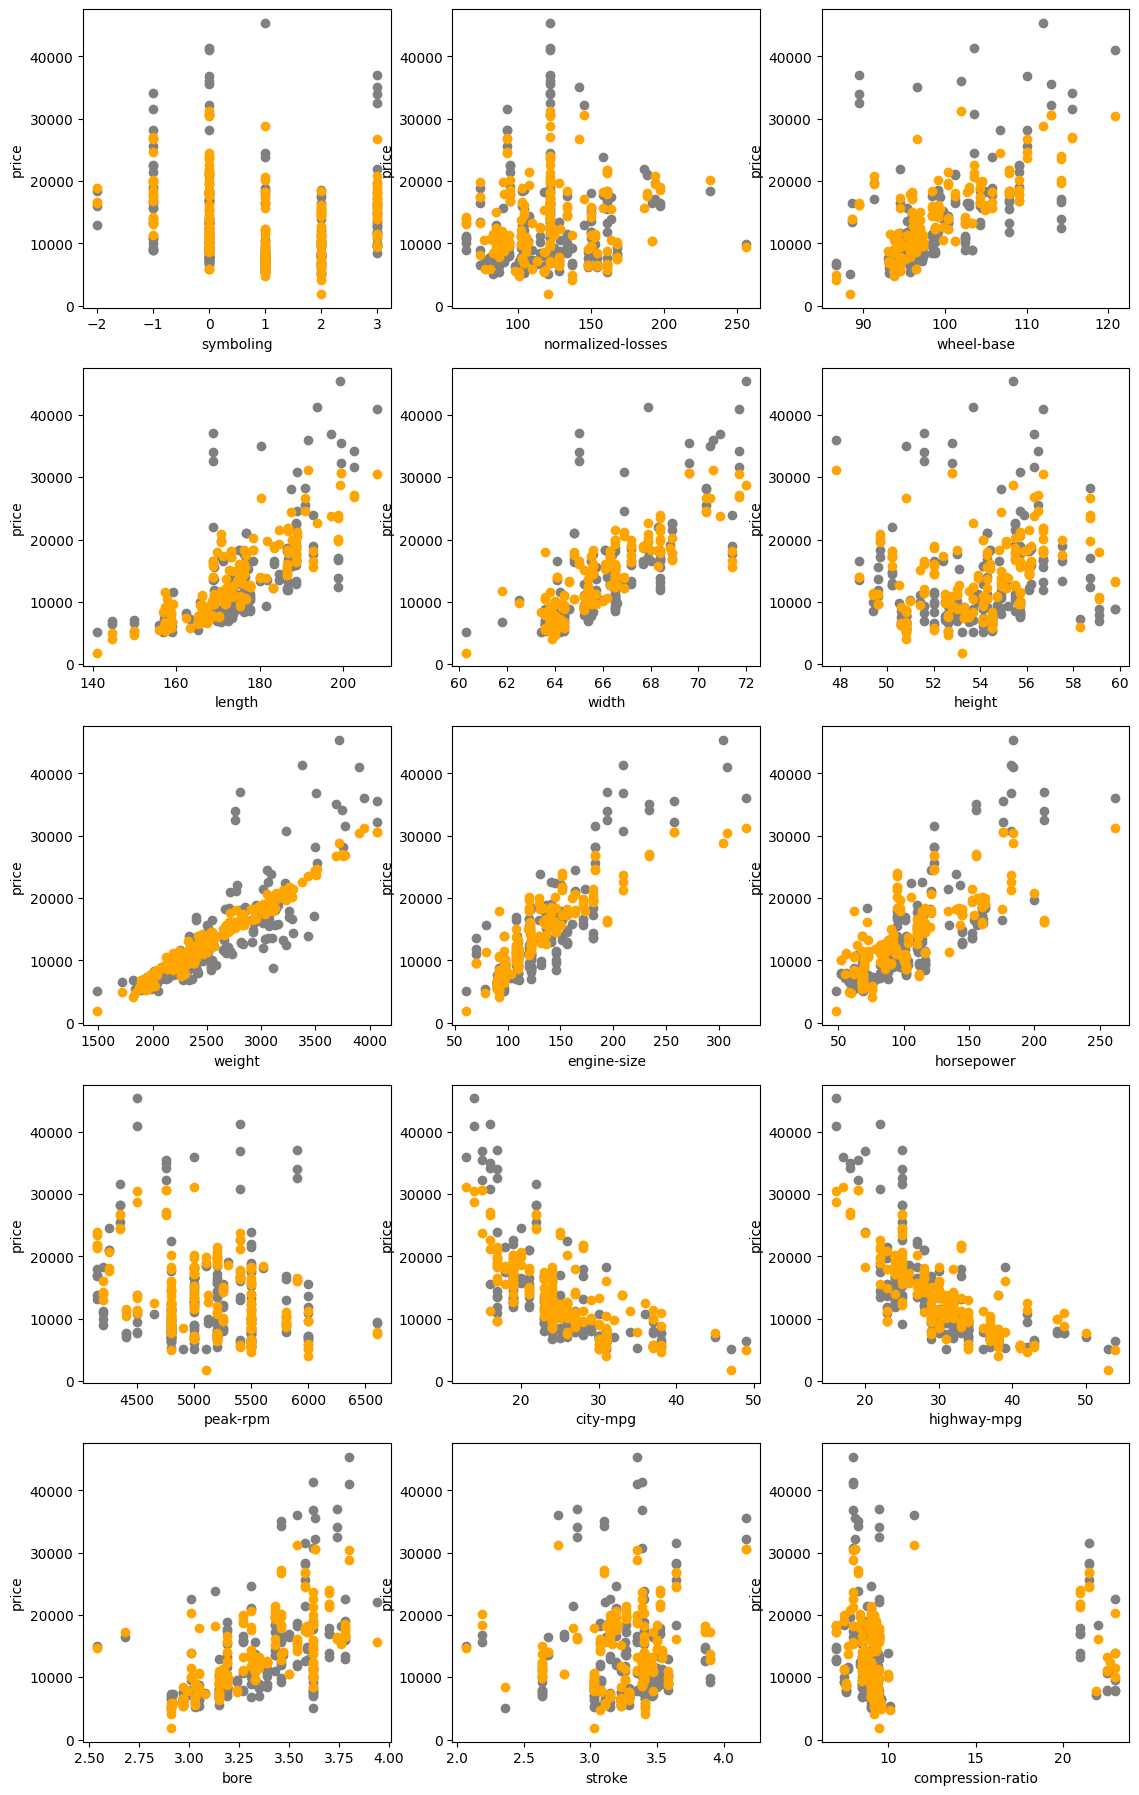

In [35]:
from matplotlib import pyplot as plt


def scatter_plot_inference_grid(est, x_df, feature_names):
  """Plots the predictions of the model against each feature.

  Args:
    est: The trained tf.Estimator.
    x_df: The pandas dataframe with the input data (used to create
      predict_input_fn).
    feature_names: An iterable of string feature names to plot.
  """
  def scatter_plot_inference(axis,
                             x_axis_feature_name,
                             y_axis_feature_name,
                             predictions):
    """Generate one subplot."""
    # Plot the real data in grey.
    y_axis_feature_name = 'price'
    axis.set_ylabel(y_axis_feature_name)
    axis.set_xlabel(x_axis_feature_name)
    axis.scatter(car_data[x_axis_feature_name],
                 car_data[y_axis_feature_name],
                 c='grey')

    # Plot the predicted data in orange.
    axis.scatter(car_data[x_axis_feature_name], predictions, c='orange')

  predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

  predictions = [
    x['predictions'][0]
    for x in est.predict(predict_input_fn)
  ]

  num_cols = 3
  num_rows = int(math.ceil(len(feature_names)/float(num_cols)))
  f, axarr = plt.subplots(num_rows, num_cols)
  size = 4.5
  f.set_size_inches(num_cols*size, num_rows*size)

  for i, feature_name in enumerate(numeric_feature_names):
    axis = axarr[int(i/num_cols), i%num_cols]
    scatter_plot_inference(axis, feature_name, 'price', predictions)
  plt.show()

scatter_plot_inference_grid(est, x_df, numeric_feature_names)

### Task 2: Take best numeric model from earlier. Add normalization.

#### Adding normalization to best numeric model from earlier

- Decide what type of normalization to add, and for which features
- Use the `normalizer_fn` arg on [`numeric_column`](https://g3doc.corp.google.com/learning/brain/public/g3doc/api_docs/python/tf/feature_column/numeric_column.md?cl=head)
    - An example of a silly normalizer_fn that shifts inputs down by 1, and then negates the value:
    
         normalizer_fn = lambda x: tf.neg(tf.subtract(x, 1))
- You may find these pandas functions helpful:
    - dataframe.mean()['your_feature_name']
    - dataframe.std()['your_feature_name']
- You will need to retune the hyperparameters from earlier.


**Does normalization improve model quality on this dataset? Why or why not?**

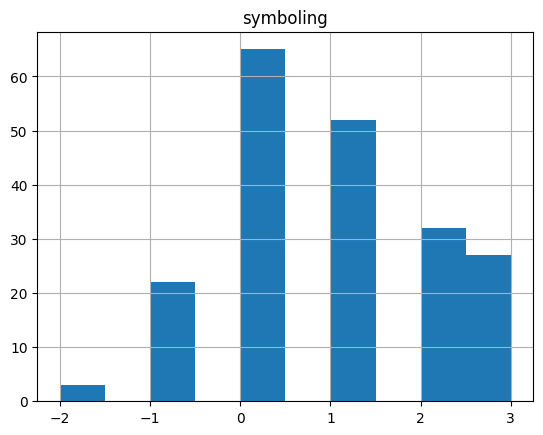

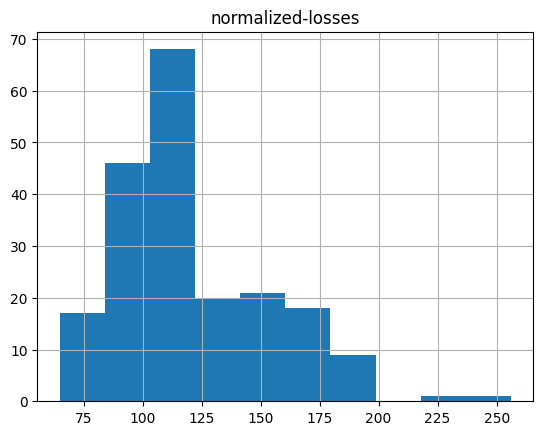

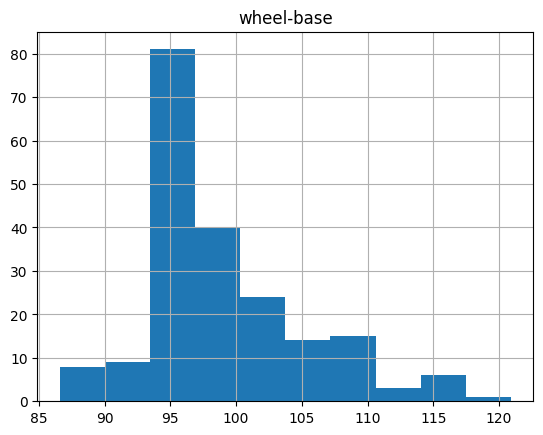

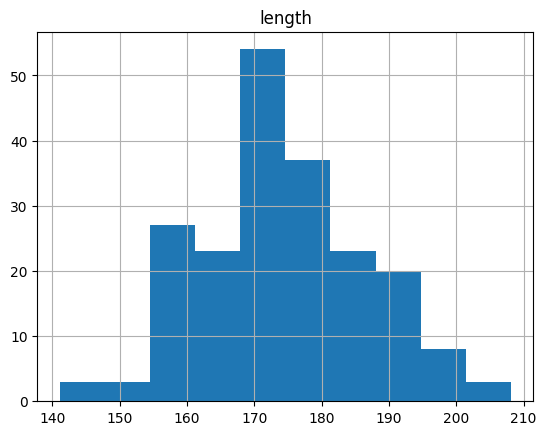

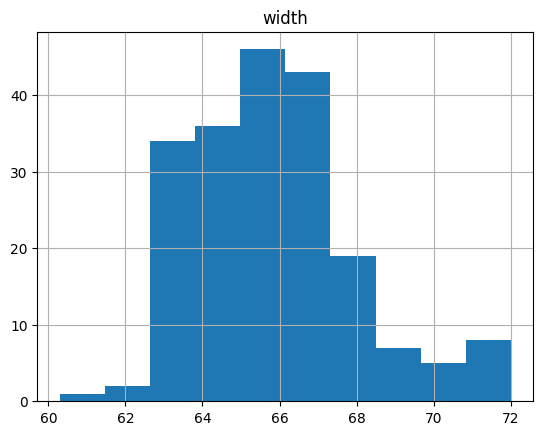

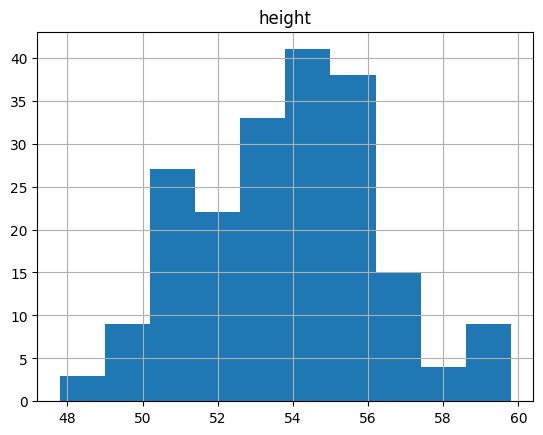

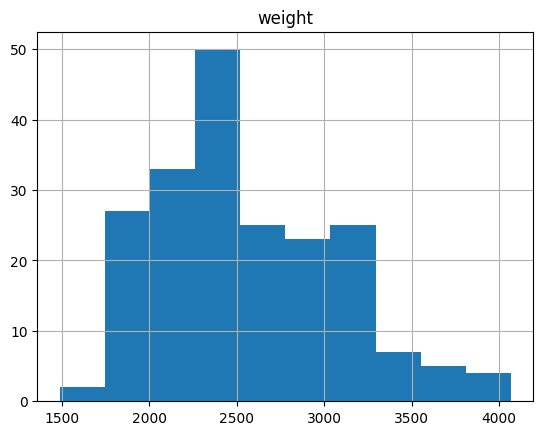

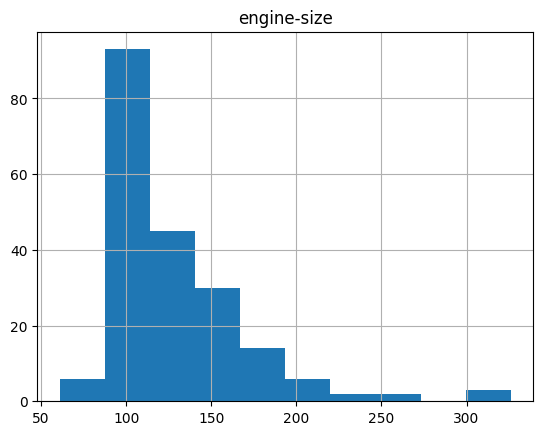

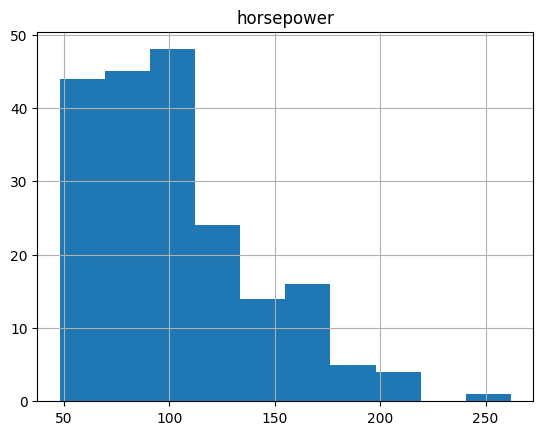

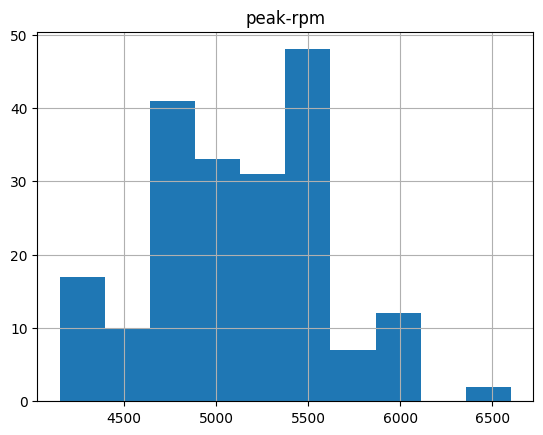

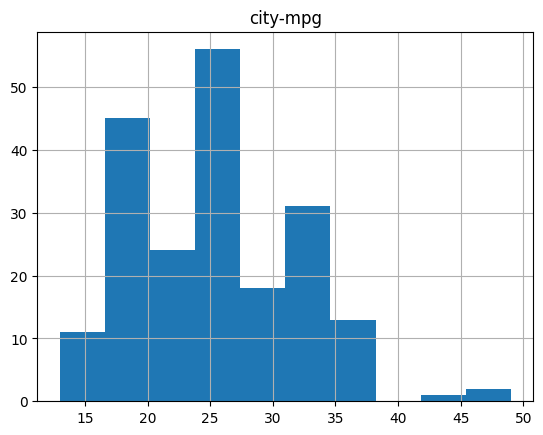

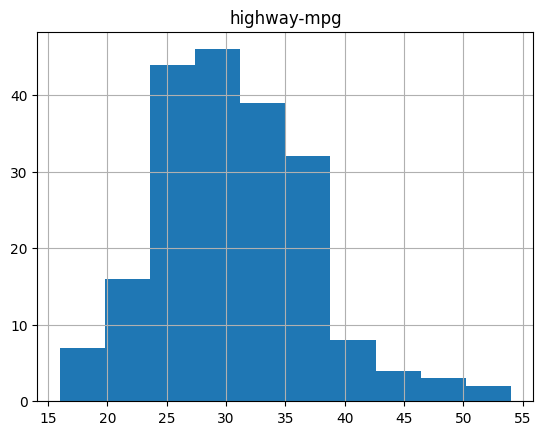

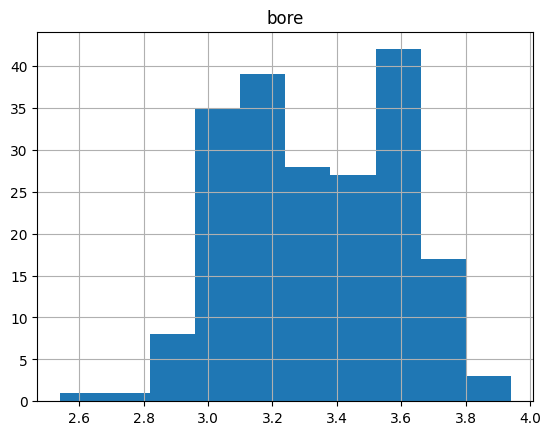

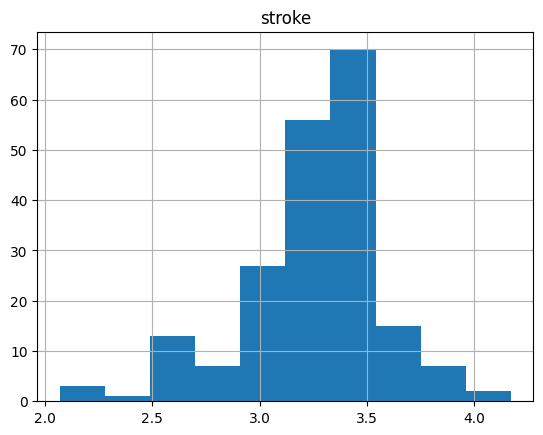

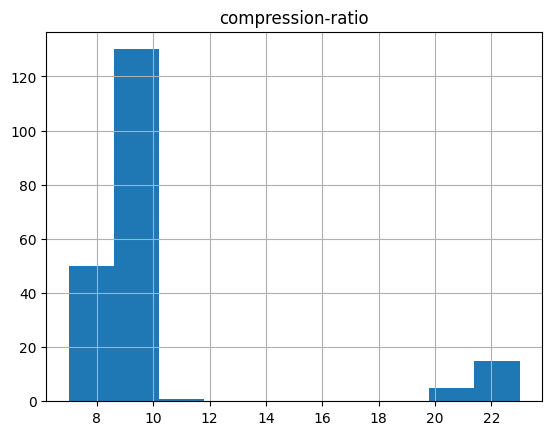

In [23]:
# This 1D visualization of each numeric feature might inform your normalization
# decisions.
for feature_name in numeric_feature_names:
  car_data.hist(column=feature_name)

### Train your model with numeric features + normalization

In [24]:
## Your code goes here

In [ ]:
#@title Possible solution
# This does Z-score normalization since the distributions for most features looked
# roughly normally distributed.

# Z-score normalization subtracts the mean and divides by the standard deviation,
# to give a roughly standard normal distribution (mean = 0, std = 1) under a
# normal distribution assumption. Epsilon prevents divide by zero.

# With normalization, are you able to get the model working with
# GradientDescentOptimizer? Z-score normalization doesn't seem to be able to get
# SGD working. Maybe a different type of normalization would?

batch_size = 16

print(numeric_feature_names)
x_df = car_data[numeric_feature_names]
y_series = car_data['price']

train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

# Epsilon prevents divide by zero.
epsilon = 0.000001
model_feature_columns = [
    tf.feature_column.numeric_column(feature_name,
                                     normalizer_fn=lambda val: (val - x_df.mean()[feature_name]) / (epsilon + x_df.std()[feature_name]))
    for feature_name in numeric_feature_names
]
print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),
  )

# TRAIN
num_print_statements = 10
num_training_steps = 10000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)

  # The `scores` dictionary has several metrics automatically generated by the
  # canned Estimator.
  # `average_loss` is the average loss for an individual example.
  # `loss` is the summed loss for the batch.
  # In addition to these scalar losses, you may find the visualization functions
  # in the next cell helpful for debugging model quality.
  print('scores', scores)

scatter_plot_inference_grid(est, x_df, numeric_feature_names)

### Task 3: Make your best model using only categorical features

- Look at the possible feature columns for categorical features. They begin with `categorical_column_with_` in go/tf-ops.
- You may find `dataframe[categorical_feature_names].unique()` helpful.


In [28]:
## Your code goes here
car_data[categorical_feature_names].unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

In [ ]:
#@title Possible solution
# We have the full list of values that each feature takes on, and the list is
# relatively small so we use categorical_column_with_vocabulary_list.

batch_size = 16

x_df = car_data[categorical_feature_names]
y_series = car_data['price']

train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

model_feature_columns = [
    tf.feature_column.indicator_column(
        tf.feature_column.categorical_column_with_vocabulary_list(
            feature_name, vocabulary_list=car_data[feature_name].unique()))
    for feature_name in categorical_feature_names
]
print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),
  )

# TRAIN
num_print_statements = 10
num_training_steps = 10000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)

  # The `scores` dictionary has several metrics automatically generated by the
  # canned Estimator.
  # `average_loss` is the average loss for an individual example.
  # `loss` is the summed loss for the batch.
  # In addition to these scalar losses, you may find the visualization functions
  # in the next cell helpful for debugging model quality.
  print('scores', scores)



### Task 4: Using all the features, make the best model that you can make

With all the features combined, your model should perform better than your earlier models using numerical and categorical models alone. Tune your model until that is the case.

In [45]:
## Your code goes here

In [ ]:
#@title Possible solution
# This is a first pass at a model that uses all the features.
# Do you have any improvements?

batch_size = 16

x_df = car_data[numeric_feature_names + categorical_feature_names]
y_series = car_data['price']

train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

epsilon = 0.000001
model_feature_columns = [
    tf.feature_column.indicator_column(
        tf.feature_column.categorical_column_with_vocabulary_list(
            feature_name, vocabulary_list=car_data[feature_name].unique()))
    for feature_name in categorical_feature_names
] + [
    tf.feature_column.numeric_column(feature_name,
                                     normalizer_fn=lambda val: (val - x_df.mean()[feature_name]) / (epsilon + x_df.std()[feature_name]))
    for feature_name in numeric_feature_names
]


print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),
  )

# TRAIN
num_print_statements = 10
num_training_steps = 10000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)

  # The `scores` dictionary has several metrics automatically generated by the
  # canned Estimator.
  # `average_loss` is the average loss for an individual example.
  # `loss` is the summed loss for the batch.
  # In addition to these scalar losses, you may find the visualization functions
  # in the next cell helpful for debugging model quality.
  print('scores', scores)

